In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

# Setup Spark (jika belum ada)
spark = SparkSession.builder \
    .appName("SimpleAggregationAnalysis") \
    .config("spark.driver.memory", "12g") \
    .getOrCreate()

In [52]:
# Load dataset
table_path = "../dataset/data/master_feature_table_final.parquet"

print(f"Memuat data dari {table_path}...")
df = spark.read.parquet(table_path)
df.cache()
df.printSchema()

Memuat data dari ../dataset/data/master_feature_table_final.parquet...
root
 |-- msno: string (nullable = true)
 |-- is_churn: integer (nullable = true)
 |-- city: integer (nullable = true)
 |-- age_group: string (nullable = true)
 |-- registered_via: integer (nullable = true)
 |-- total_transactions: long (nullable = true)
 |-- total_plan_days: long (nullable = true)
 |-- total_amount_paid: double (nullable = true)
 |-- avg_amount_paid: double (nullable = true)
 |-- count_auto_renew: long (nullable = true)
 |-- count_cancel: long (nullable = true)
 |-- most_frequent_payment_method: integer (nullable = true)
 |-- days_since_last_activity: integer (nullable = true)
 |-- total_secs_last_30d: double (nullable = true)
 |-- active_days_last_30d: long (nullable = true)
 |-- total_secs_last_90d: double (nullable = true)
 |-- active_days_last_90d: long (nullable = true)
 |-- percent_complete_last_30d: double (nullable = true)
 |-- lifetime_active_days: long (nullable = true)
 |-- lifetime_unq_

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pyspark.sql import functions as F

# --- DEFINISI FUNGSI VISUALISASI ---

def plot_churn_impact_horizontal(df, col_name, title, top_n=None):
    """Versi 1: Horizontal Bar (Absolute Impact - Jumlah Orang)"""
    stats_df = df.withColumn(col_name, F.col(col_name).cast("string")) \
        .fillna('Unknown', subset=[col_name]) \
        .groupBy(col_name) \
        .agg(F.avg("is_churn").alias("churn_rate"), F.count("msno").alias("total_users")) \
        .withColumn("total_churned_users", F.col("total_users") * F.col("churn_rate")) \
        .filter(F.col("total_users") > 50) \
        .orderBy(F.desc("total_churned_users"))
    
    if top_n: stats_df = stats_df.limit(top_n)
    pdf = stats_df.toPandas()
    
    plt.figure(figsize=(14, max(6, len(pdf)*0.5)))
    ax = sns.barplot(data=pdf, x='total_churned_users', y=col_name, color='#c44e52')
    max_x = pdf['total_churned_users'].max()
    ax.set_xlim(0, max_x * 1.3)
    
    for index, row in pdf.iterrows():
        val = row['total_churned_users']
        label = f"{int(val/1000)}k ({row['churn_rate']:.1%})" if val > 1000 else f"{int(val)} ({row['churn_rate']:.1%})"
        ax.text(val + (max_x * 0.01), index, label, color='black', va="center", fontweight='bold')
    
    plt.title(f"{title}\n(Impact: Jumlah User Churn)", fontsize=14)
    plt.show()

def plot_stacked_churn(df, col_name, title, sort_by_risk=False, top_n=None):
    """
    - Menambah Margin Atas (Y-Limit) agar label 'n=...' tidak terpotong.
    - Logika Sorting Top N aman.
    """
    
    # 1. Agregasi Data
    stats_df = df.withColumn(col_name, F.col(col_name).cast("string")) \
        .fillna('Unknown', subset=[col_name]) \
        .groupBy(col_name) \
        .agg(
            F.avg("is_churn").alias("churn_rate"),
            F.count("msno").alias("total_users")
        )
    
    # Filter data noise
    stats_df = stats_df.filter(F.col("total_users") > 50)

    # 2. Sorting Logic
    # A. Limit Top N (Populasi Terbanyak)
    if top_n:
        stats_df = stats_df.orderBy(F.desc("total_users")).limit(top_n)

    # B. Sort Tampilan (Risk atau Nama)
    if sort_by_risk:
        stats_df = stats_df.orderBy(F.desc("churn_rate"))
    else:
        stats_df = stats_df.orderBy(col_name)

    # 3. Konversi ke Pandas
    pdf = stats_df.toPandas()
    pdf['retention_rate'] = 1 - pdf['churn_rate']

    # 4. Plotting
    plt.figure(figsize=(14, 8)) # Perbesar tinggi kanvas sedikit (7 -> 8)
    
    # Bar Bawah (Retained)
    plt.bar(pdf[col_name], pdf['retention_rate'], label='Retained (Tidak Churn)', color='#4c72b0', edgecolor='white')
    
    # Bar Atas (Churned)
    plt.bar(pdf[col_name], pdf['churn_rate'], bottom=pdf['retention_rate'], label='Churned', color='#c44e52', edgecolor='white')
    
    # 5. Labeling
    # [PERBAIKAN UTAMA] Set batas atas jadi 1.25 (125%) biar lega
    plt.ylim(0, 1.25)
    
    for index, row in pdf.iterrows():
        # Label Persen (di tengah merah)
        if row['churn_rate'] > 0.02: 
            plt.text(index, row['retention_rate'] + (row['churn_rate']/2), 
                     f"{row['churn_rate']:.1%}", 
                     color='white', ha="center", va="center", fontweight='bold', fontsize=10)
        
        # Label Jumlah User (n=...) di atas batang
        label_n = f"n={int(row['total_users']/1000)}k" if row['total_users'] > 1000 else f"n={row['total_users']}"
        
        # Taruh label di posisi 1.02 (sedikit di atas batang full)
        plt.text(index, 1.02, label_n, color='black', ha="center", va="bottom", fontsize=9)

    plt.title(title, fontsize=16, pad=20)
    plt.xlabel(col_name, fontsize=12)
    plt.ylabel('Proporsi User (0.0 - 1.0)', fontsize=12)
    
    # Legenda ditaruh di luar (atas kanan) agar tidak menutupi data
    plt.legend(bbox_to_anchor=(1.0, 1.1), loc='upper right')
    
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

Melakukan Binning untuk SEMUA fitur...
Binning Selesai!


--- 1. ANALISIS DEMOGRAFI ---


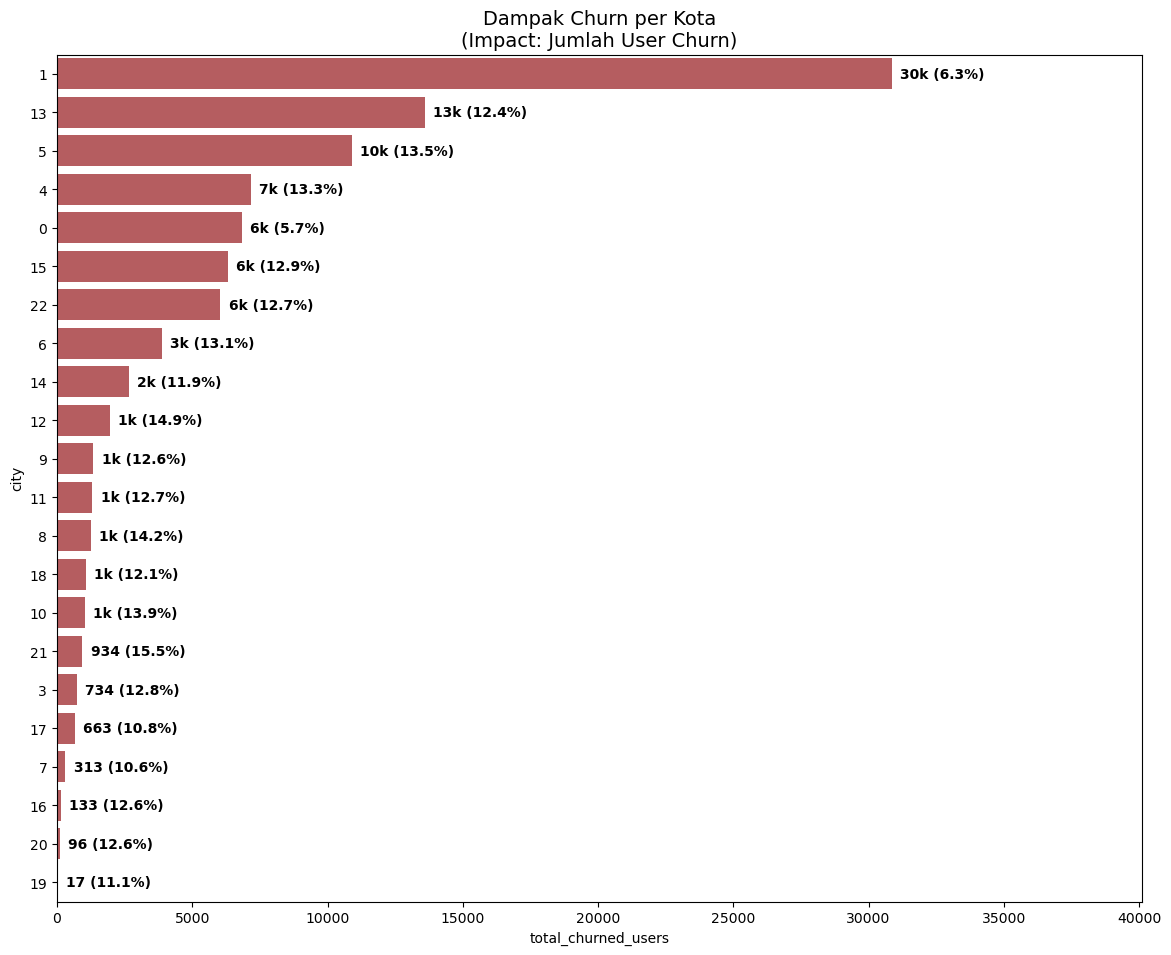

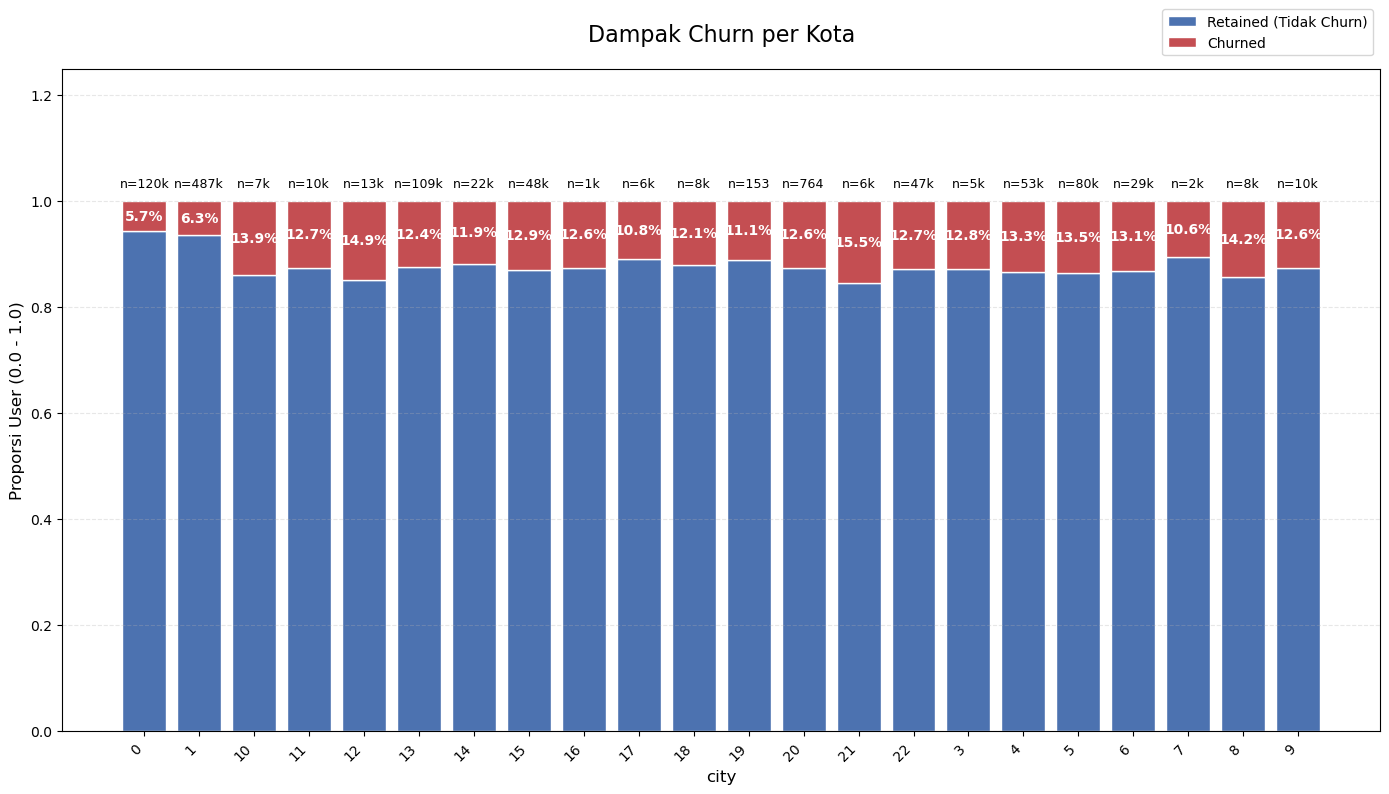

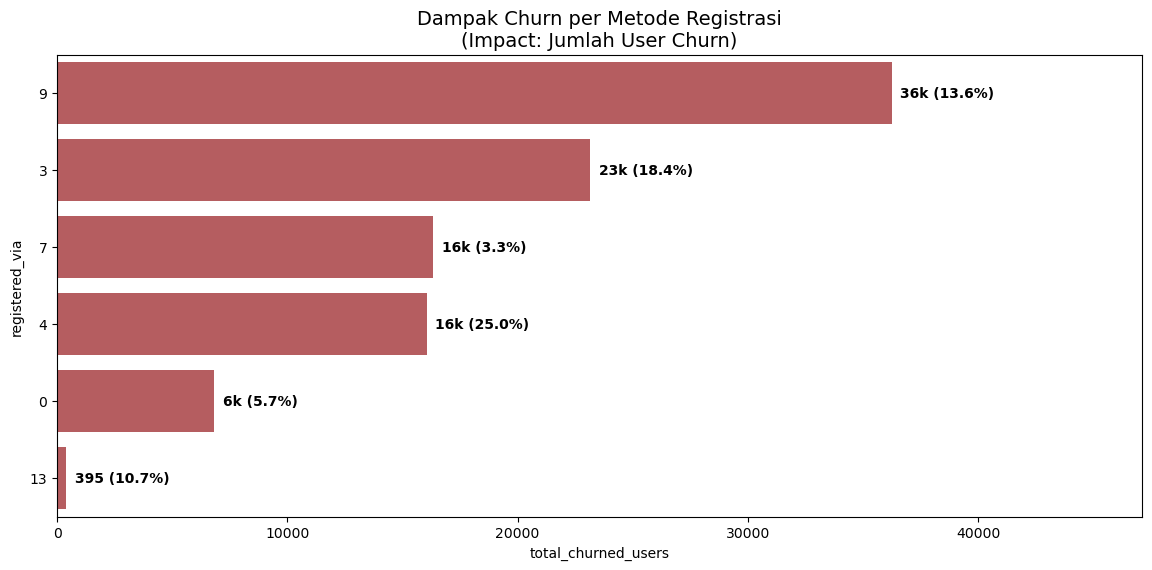

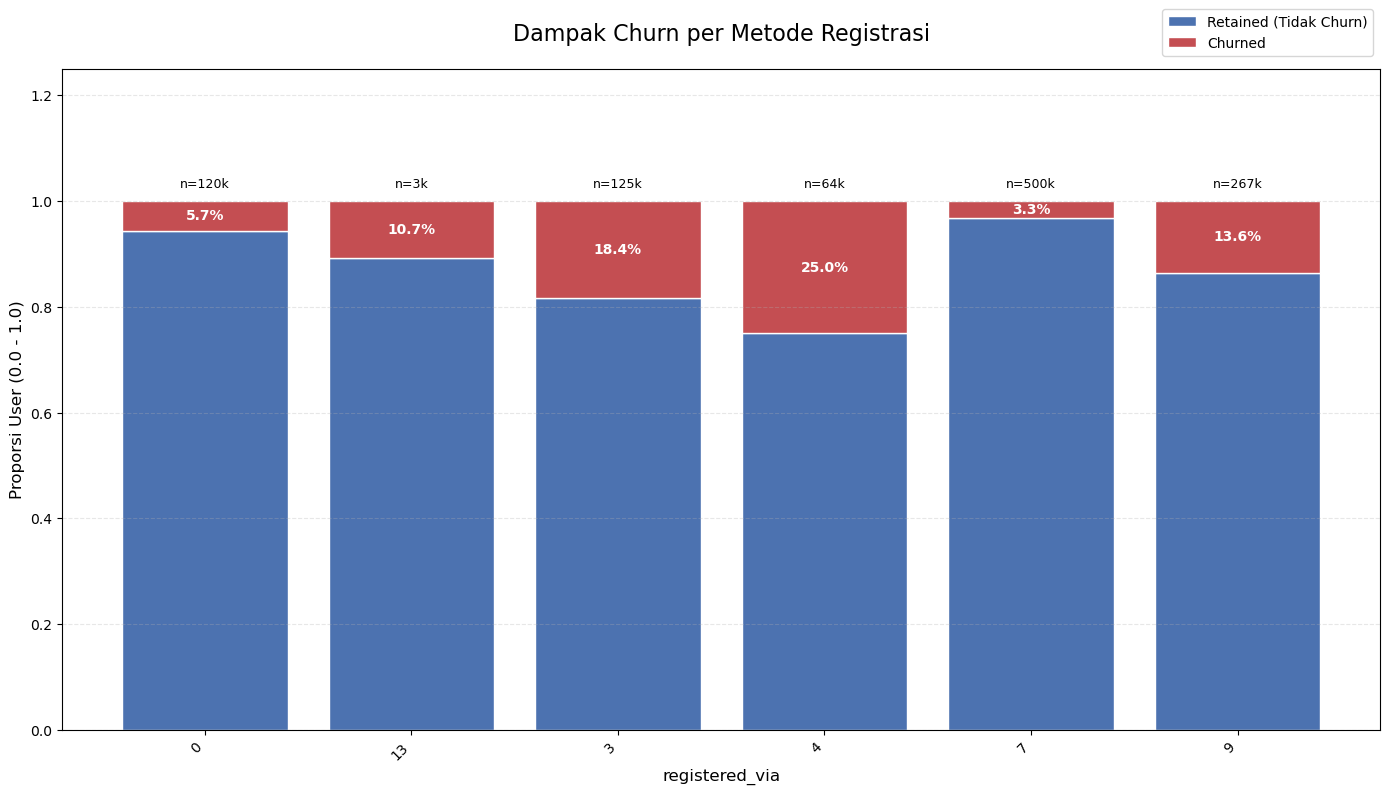

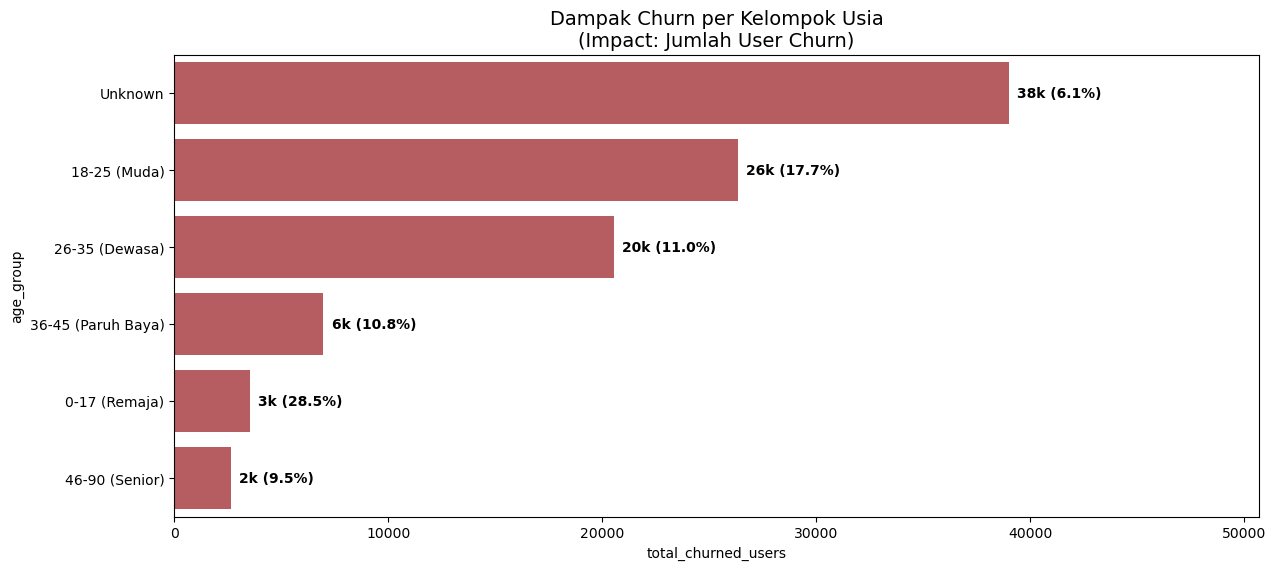

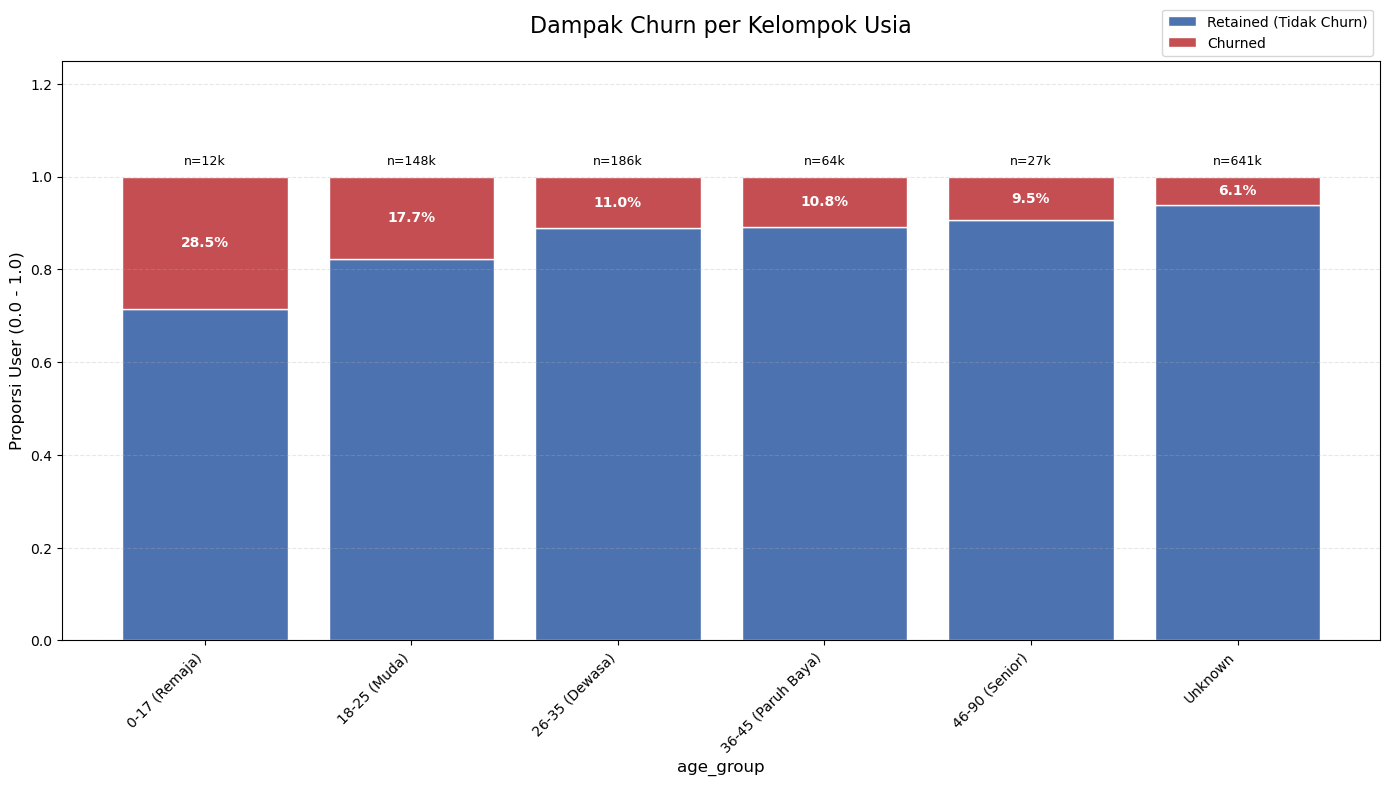

In [ ]:
print("--- 1. ANALISIS DEMOGRAFI ---")

# A. Analisis Kota
# Sort by 'impact' untuk melihat kota mana penyumbang churn terbanyak (bukan cuma persentase)
plot_churn_impact_horizontal(df, "city", "Dampak Churn per Kota")
plot_stacked_churn(df, "city", "Dampak Churn per Kota")

# B. Analisis Metode Registrasi
plot_churn_impact_horizontal(df, "registered_via", "Dampak Churn per Metode Registrasi")
plot_stacked_churn(df, "registered_via", "Dampak Churn per Metode Registrasi")

# C. Analisis Age Group
plot_churn_impact_horizontal(df, "age_group", "Dampak Churn per Kelompok Usia")
plot_stacked_churn(df, "age_group", "Dampak Churn per Kelompok Usia")

=== ANALISIS TRANSAKSI ===


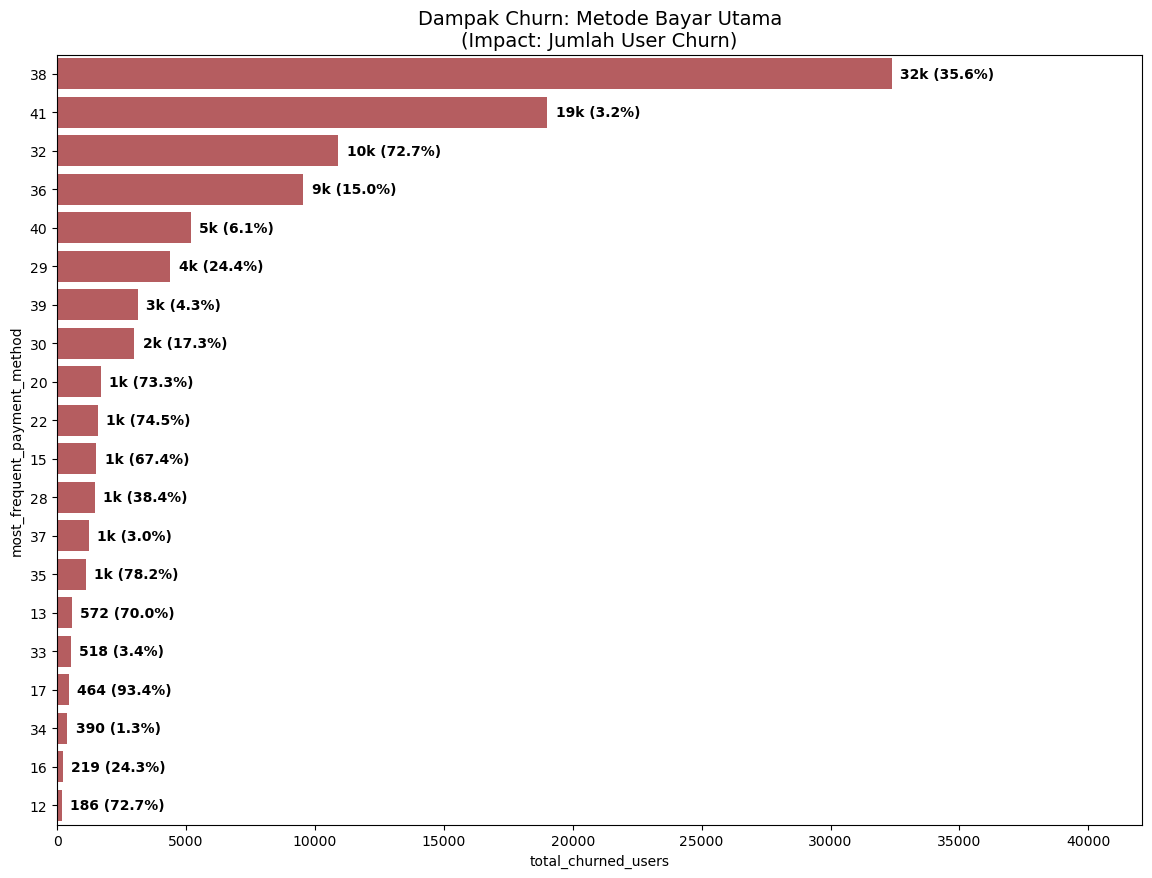

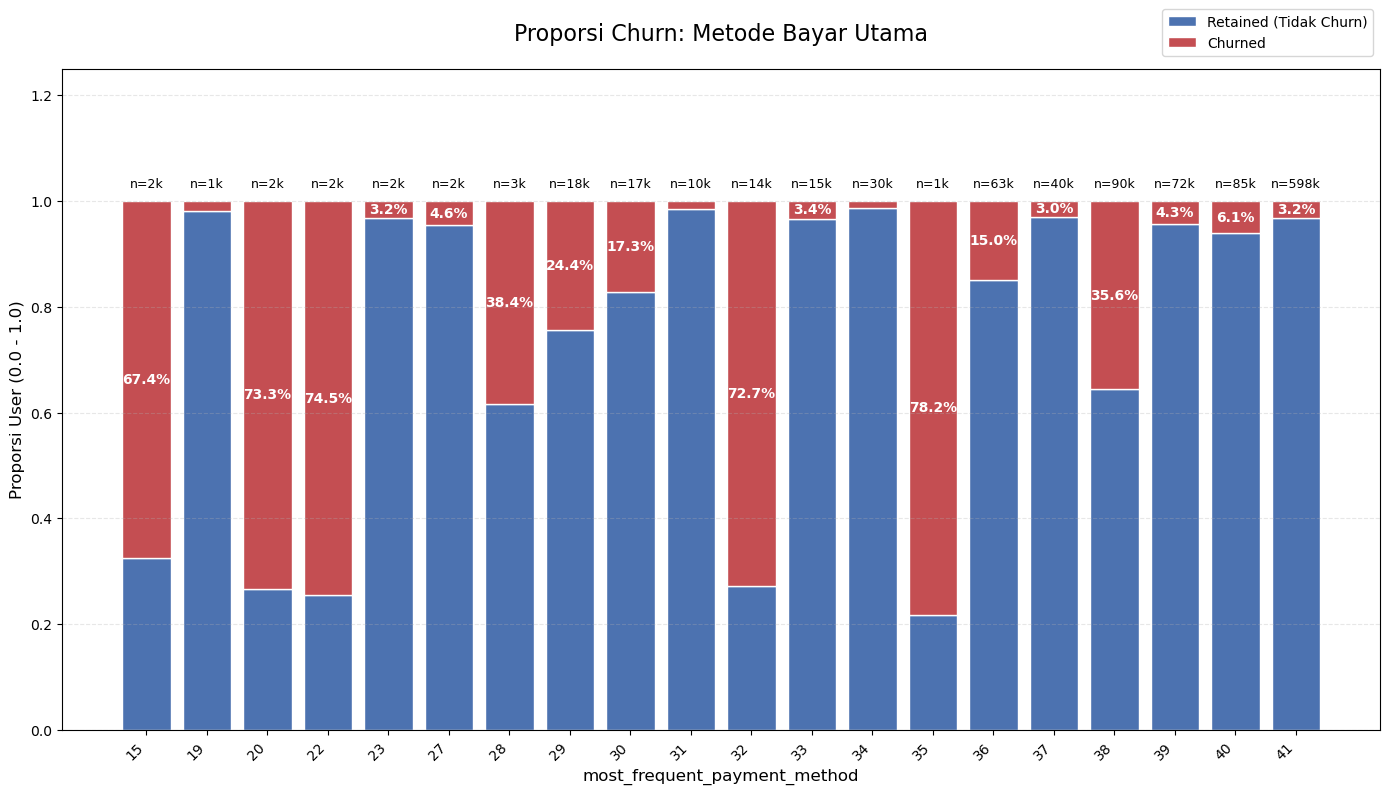

In [ ]:
print("=== ANALISIS TRANSAKSI ===")

# Most Frequent Payment (Top 20)
plot_churn_impact_horizontal(df, "most_frequent_payment_method", "Dampak Churn: Metode Bayar Utama", top_n=20)
plot_stacked_churn(df, "most_frequent_payment_method", "Proporsi Churn: Metode Bayar Utama", top_n=20)

Mengambil sampel data untuk visualisasi Boxplot...
--- VISUALISASI BOXPLOT (DISTRIBUSI ASLI) ---


C:\Users\ASUS\AppData\Local\Temp\ipykernel_6668\350276065.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x="is_churn", y=y_col, palette=["#4c72b0", "#c44e52"])


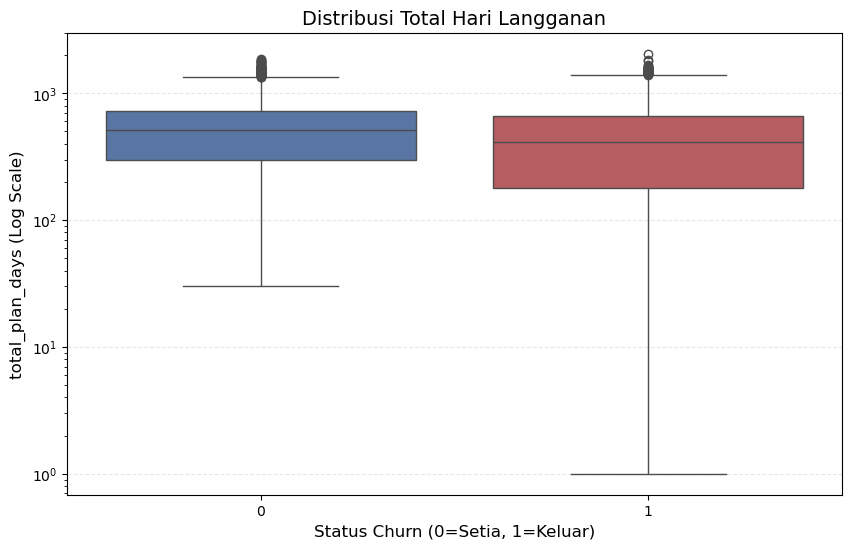

C:\Users\ASUS\AppData\Local\Temp\ipykernel_6668\350276065.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x="is_churn", y=y_col, palette=["#4c72b0", "#c44e52"])


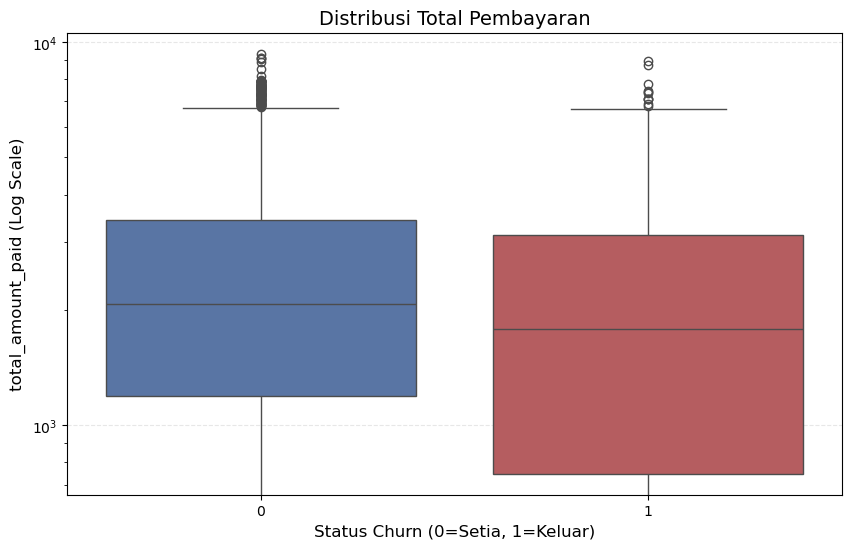

C:\Users\ASUS\AppData\Local\Temp\ipykernel_6668\350276065.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x="is_churn", y=y_col, palette=["#4c72b0", "#c44e52"])


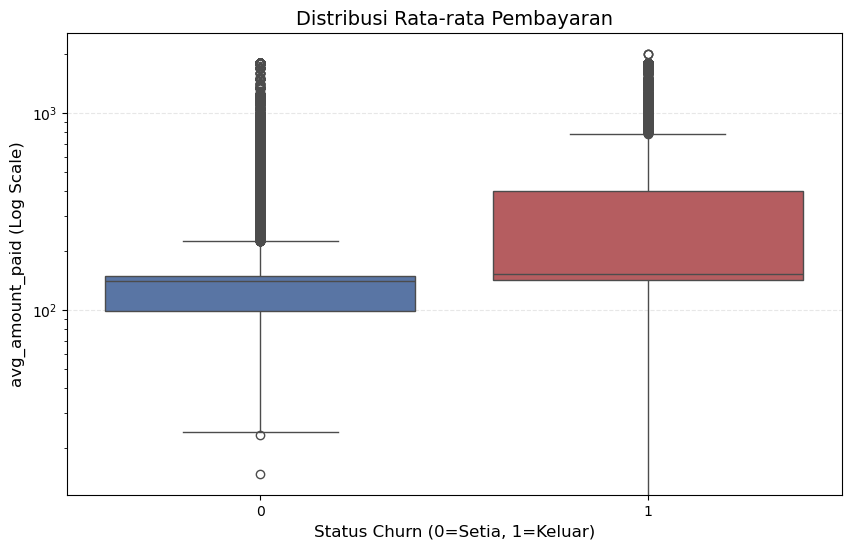

C:\Users\ASUS\AppData\Local\Temp\ipykernel_6668\350276065.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x="is_churn", y=y_col, palette=["#4c72b0", "#c44e52"])


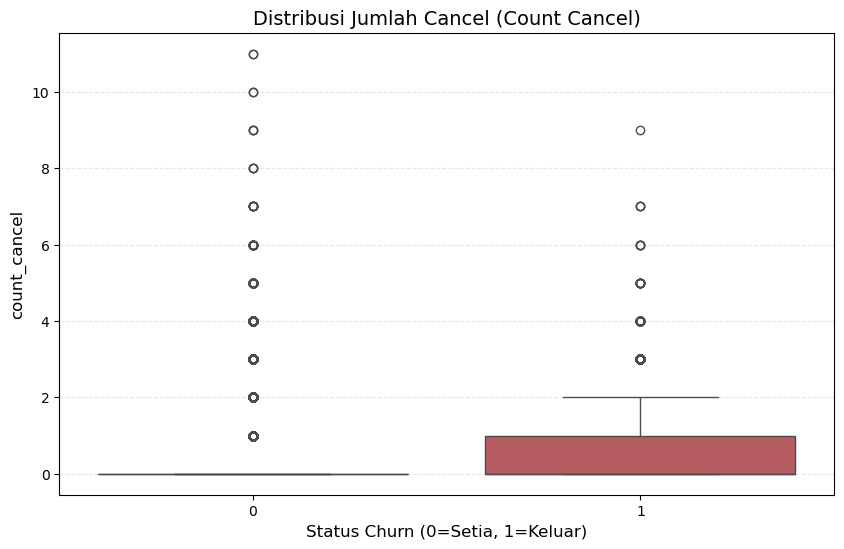

C:\Users\ASUS\AppData\Local\Temp\ipykernel_6668\350276065.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x="is_churn", y=y_col, palette=["#4c72b0", "#c44e52"])


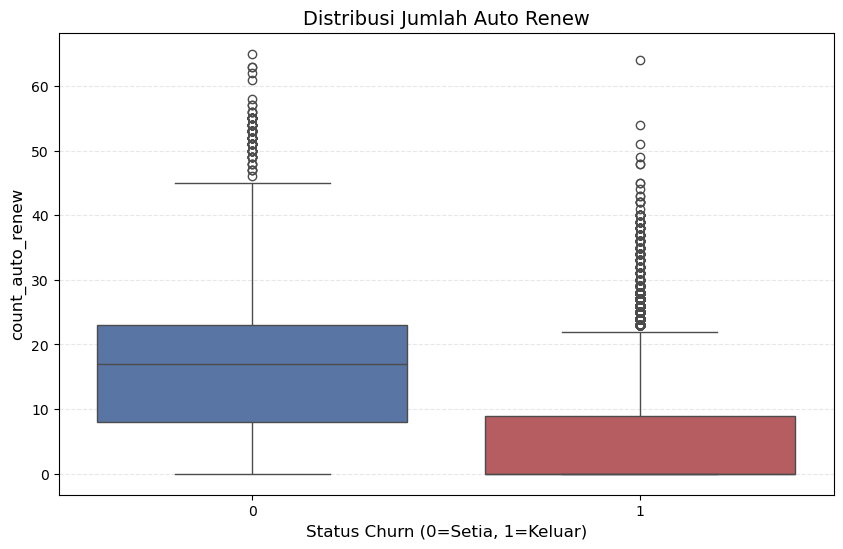

C:\Users\ASUS\AppData\Local\Temp\ipykernel_6668\350276065.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x="is_churn", y=y_col, palette=["#4c72b0", "#c44e52"])


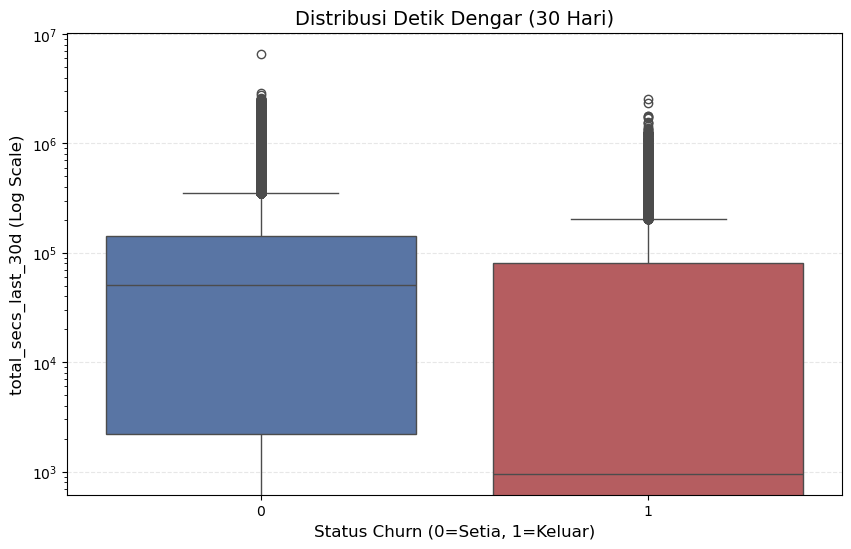

C:\Users\ASUS\AppData\Local\Temp\ipykernel_6668\350276065.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x="is_churn", y=y_col, palette=["#4c72b0", "#c44e52"])


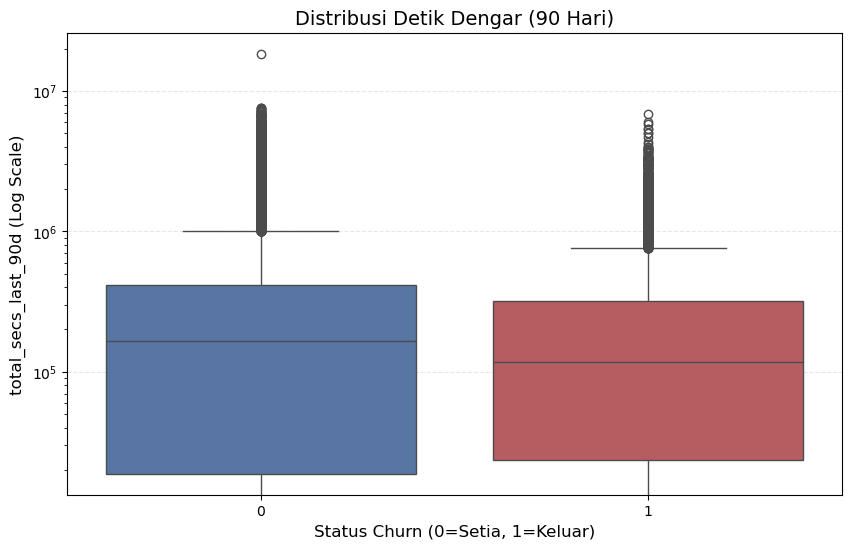

C:\Users\ASUS\AppData\Local\Temp\ipykernel_6668\350276065.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x="is_churn", y=y_col, palette=["#4c72b0", "#c44e52"])


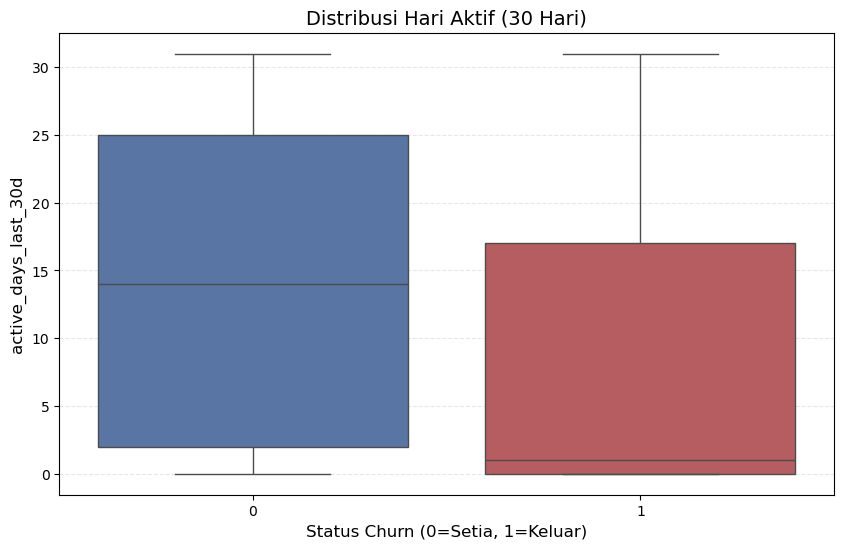

C:\Users\ASUS\AppData\Local\Temp\ipykernel_6668\350276065.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x="is_churn", y=y_col, palette=["#4c72b0", "#c44e52"])


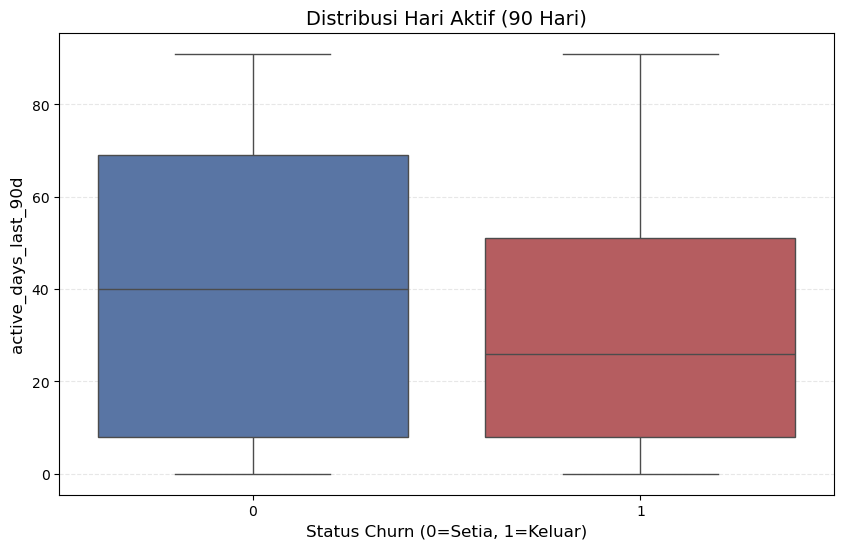

C:\Users\ASUS\AppData\Local\Temp\ipykernel_6668\350276065.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x="is_churn", y=y_col, palette=["#4c72b0", "#c44e52"])


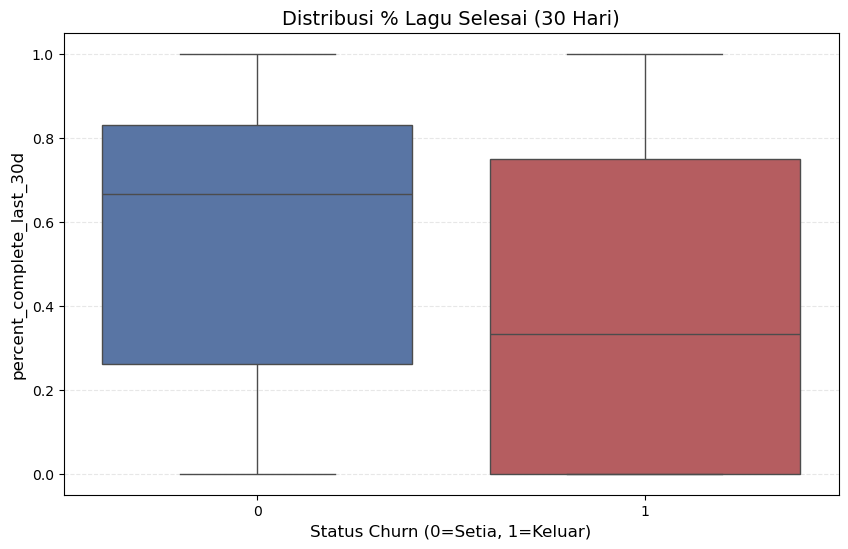

C:\Users\ASUS\AppData\Local\Temp\ipykernel_6668\350276065.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x="is_churn", y=y_col, palette=["#4c72b0", "#c44e52"])


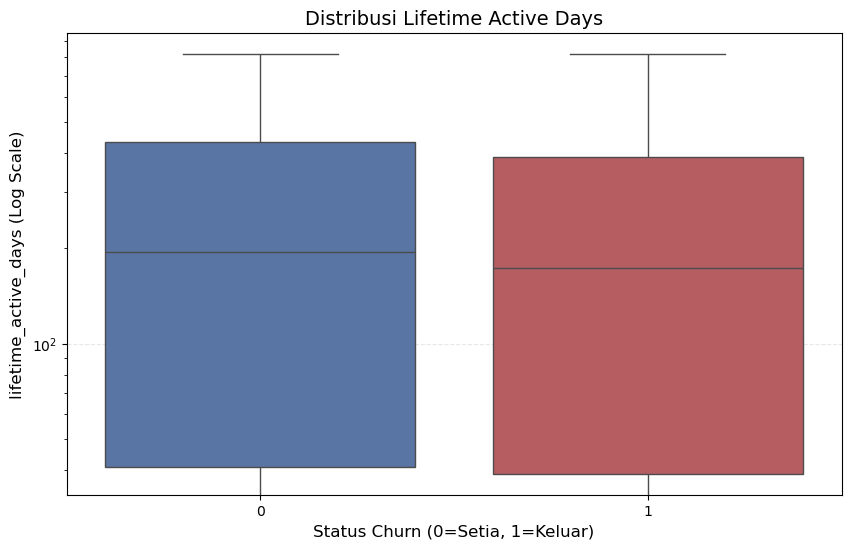

C:\Users\ASUS\AppData\Local\Temp\ipykernel_6668\350276065.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x="is_churn", y=y_col, palette=["#4c72b0", "#c44e52"])


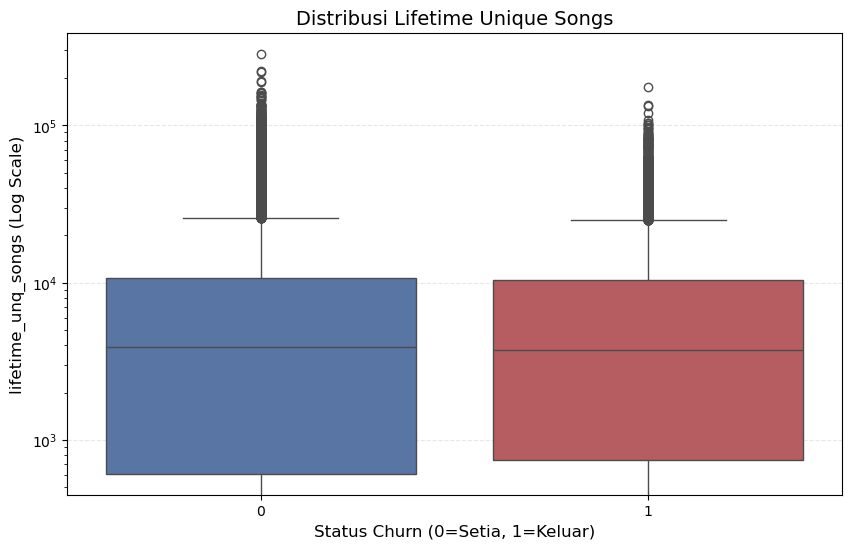

C:\Users\ASUS\AppData\Local\Temp\ipykernel_6668\350276065.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x="is_churn", y=y_col, palette=["#4c72b0", "#c44e52"])


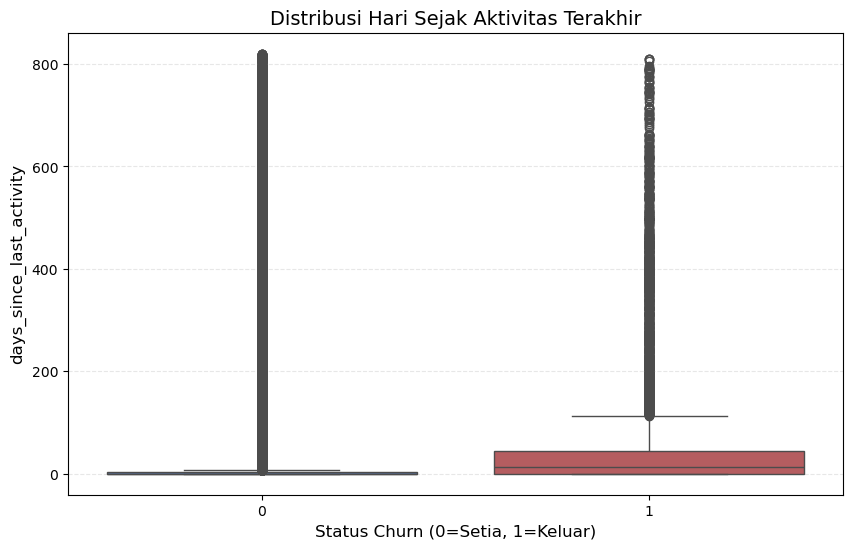

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Load Data
cols_to_plot = [
    "is_churn", 
    "total_plan_days", 
    "total_amount_paid", 
    "avg_amount_paid", 
    "count_cancel",
    "count_auto_renew",
    "total_secs_last_30d",
    "total_secs_last_90d",
    "active_days_last_30d",
    "active_days_last_90d",
    "percent_complete_last_30d",
    "lifetime_active_days",
    "lifetime_unq_songs",
    "days_since_last_activity"
]

# Ambil sample 20% data agar plotting tidak terlalu berat (jika data > 1 juta baris)
print("Mengambil sampel data untuk visualisasi Boxplot...")
pdf_box = df.select(cols_to_plot).sample(fraction=0.2, seed=42).toPandas()

# 2. Definisi Fungsi Boxplot
def plot_boxplot(data, y_col, title, log_scale=False):
    plt.figure(figsize=(10, 6))
    
    # Gambar Boxplot
    sns.boxplot(data=data, x="is_churn", y=y_col, palette=["#4c72b0", "#c44e52"])
    
    # Judul & Label
    plt.title(title, fontsize=14)
    plt.xlabel("Status Churn (0=Setia, 1=Keluar)", fontsize=12)
    plt.ylabel(y_col, fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    
    # Log Scale untuk data yang jomplang (seperti uang/harga)
    if log_scale:
        plt.yscale('log')
        plt.ylabel(f"{y_col} (Log Scale)")
    
    plt.show()

print("--- VISUALISASI BOXPLOT (DISTRIBUSI ASLI) ---")

plot_boxplot(pdf_box, "total_plan_days", "Distribusi Total Hari Langganan", log_scale=True)
plot_boxplot(pdf_box, "total_amount_paid", "Distribusi Total Pembayaran", log_scale=True)
plot_boxplot(pdf_box, "avg_amount_paid", "Distribusi Rata-rata Pembayaran", log_scale=True)

plot_boxplot(pdf_box, "count_cancel", "Distribusi Jumlah Cancel (Count Cancel)", log_scale=False)
plot_boxplot(pdf_box, "count_auto_renew", "Distribusi Jumlah Auto Renew", log_scale=False)

plot_boxplot(pdf_box, "total_secs_last_30d", "Distribusi Detik Dengar (30 Hari)", log_scale=True)
plot_boxplot(pdf_box, "total_secs_last_90d", "Distribusi Detik Dengar (90 Hari)", log_scale=True)

plot_boxplot(pdf_box, "active_days_last_30d", "Distribusi Hari Aktif (30 Hari)", log_scale=False) 
plot_boxplot(pdf_box, "active_days_last_90d", "Distribusi Hari Aktif (90 Hari)", log_scale=False)

plot_boxplot(pdf_box, "percent_complete_last_30d", "Distribusi % Lagu Selesai (30 Hari)", log_scale=False)

plot_boxplot(pdf_box, "lifetime_active_days", "Distribusi Lifetime Active Days", log_scale=True)
plot_boxplot(pdf_box, "lifetime_unq_songs", "Distribusi Lifetime Unique Songs", log_scale=True)

plot_boxplot(pdf_box, "days_since_last_activity", "Distribusi Hari Sejak Aktivitas Terakhir", log_scale=False)
